In [ ]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

DB = '../data/humans_clean.sqlite3'

# 5 polities across different civilisations
polities = [
    ('Roman Empire',        "c.polity_name LIKE 'Roman Empire%'"),
    ('Tang Dynasty',        "c.polity_name LIKE 'Tang Dynasty%'"),
    ('Kingdom of France',   "c.polity_name LIKE '%Kingdom of France%'"),
    ('Safavid Dynasty',     "c.polity_name LIKE '%Safavid Dynasty%'"),
    ('Kingdom of England',  "c.polity_name LIKE '%Kingdom of England%'"),
]


def shannon_entropy(counts_dict, top_keys):
    vals = [counts_dict.get(k, 0) for k in top_keys]
    total = sum(vals)
    if total == 0:
        return np.nan
    probs = np.array([v / total for v in vals if v > 0])
    return -np.sum(probs * np.log2(probs))

In [2]:
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

results = []

for title, where in polities:
    cur = conn.execute(f'''
        SELECT MIN(c.impact_year), MAX(c.impact_year), COUNT(*)
        FROM consolidate c
        WHERE ({where}) AND c.impact_year IS NOT NULL
    ''')
    yr_start, yr_end, total_count = cur.fetchone()

    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"  Date range: {yr_start} – {yr_end}")
    print(f"  Total individuals: {total_count:,}")

    cur = conn.execute(f'''
        SELECT c.occupations, c.impact_year, c.is_scientist, c.is_artist
        FROM consolidate c
        WHERE ({where})
          AND c.occupations IS NOT NULL
          AND c.impact_year IS NOT NULL
    ''')

    all_counter = Counter()
    sci_counter = Counter()
    art_counter = Counter()
    bin_all = defaultdict(Counter)
    bin_sci = defaultdict(Counter)
    bin_art = defaultdict(Counter)

    n_rows = 0
    for occs_str, year, is_sci, is_art in cur:
        if not occs_str:
            continue
        # Round to nearest 50
        t = ((year + 25) // 50) * 50
        for occ in occs_str.split('; '):
            occ = occ.strip().lower()
            if not occ:
                continue
            all_counter[occ] += 1
            bin_all[t][occ] += 1
            if is_sci:
                sci_counter[occ] += 1
                bin_sci[t][occ] += 1
            if is_art:
                art_counter[occ] += 1
                bin_art[t][occ] += 1
        n_rows += 1

    top10_all = [o for o, _ in all_counter.most_common(10)]
    top10_sci = [o for o, _ in sci_counter.most_common(10)]
    top10_art = [o for o, _ in art_counter.most_common(10)]

    print(f"  n = {n_rows:,}")
    print(f"\n  Top 10 occupations (from data):")
    for o, c in all_counter.most_common(10):
        print(f"    {o}: {c:,}")
    print(f"\n  Top 10 scientific (from data, is_scientist=1):")
    for o, c in sci_counter.most_common(10):
        print(f"    {o}: {c:,}")
    print(f"\n  Top 10 artistic (from data, is_artist=1):")
    for o, c in art_counter.most_common(10):
        print(f"    {o}: {c:,}")

    # Only keep complete bins: bin B covers [B-25, B+24],
    # so it is complete when B-25 >= yr_start and B+24 <= yr_end
    complete_bins = sorted(b for b in bin_all
                           if b - 25 >= yr_start and b + 24 <= yr_end)

    h_all = [shannon_entropy(bin_all[b], top10_all) for b in complete_bins]
    h_sci = [shannon_entropy(bin_sci[b], top10_sci) for b in complete_bins]
    h_art = [shannon_entropy(bin_art[b], top10_art) for b in complete_bins]

    if complete_bins:
        print(f"  Plotted bins: {complete_bins[0]} – {complete_bins[-1]}")
    else:
        print("  No complete bins!")

    results.append((title, yr_start, yr_end, complete_bins, h_all, h_sci, h_art, n_rows))

conn.close()


Roman Empire
  Date range: -30 – 394
  Total individuals: 4,282


  n = 3,282

  Top 10 occupations (from data):
    politician: 1,556
    military personnel: 530
    writer: 295
    catholic priest: 216
    presbyter: 171
    philosopher: 139
    poet: 108
    military officer: 95
    soldier: 81
    historian: 78

  Top 10 scientific (from data, is_scientist=1):
    writer: 139
    philosopher: 139
    historian: 78
    theologian: 59
    politician: 40
    grammarian: 36
    poet: 34
    military personnel: 28
    orator: 18
    presbyter: 18

  Top 10 artistic (from data, is_artist=1):
    writer: 295
    poet: 108
    politician: 59
    historian: 56
    philosopher: 56
    military personnel: 37
    theologian: 29
    catholic priest: 25
    grammarian: 21
    presbyter: 18
  Plotted bins: 0 – 350



Tang Dynasty
  Date range: 623 – 910
  Total individuals: 25,437


  n = 1,995

  Top 10 occupations (from data):
    poet: 932
    politician: 541
    military personnel: 262
    writer: 211
    calligrapher: 158
    painter: 66
    buddhist monk: 53
    military leader: 41
    official: 31
    historian: 27

  Top 10 scientific (from data, is_scientist=1):
    poet: 28
    historian: 27
    philosopher: 16
    buddhist monk: 13
    writer: 12
    economist: 8
    calligrapher: 8
    zen master: 7
    politician: 7
    astronomer: 4

  Top 10 artistic (from data, is_artist=1):
    poet: 932
    writer: 211
    calligrapher: 158
    politician: 82
    painter: 30
    buddhist monk: 21
    official: 19
    historian: 12
    military personnel: 9
    philosopher: 9
  Plotted bins: 650 – 850



Kingdom of France
  Date range: 990 – 1847
  Total individuals: 47,604


  n = 43,177

  Top 10 occupations (from data):
    politician: 7,600
    painter: 3,226
    writer: 3,216
    catholic priest: 3,194
    military personnel: 2,081
    catholic bishop: 1,880
    military officer: 1,759
    official: 1,696
    magistrate: 1,589
    poet: 1,457

  Top 10 scientific (from data, is_scientist=1):
    historian: 1,184
    writer: 928
    theologian: 747
    botanist: 531
    translator: 447
    philosopher: 426
    physician: 414
    politician: 414
    mathematician: 397
    university teacher: 386

  Top 10 artistic (from data, is_artist=1):
    writer: 3,216
    poet: 1,457
    composer: 1,148
    playwright: 861
    translator: 462
    actor: 412
    historian: 403
    journalist: 335
    politician: 330
    painter: 258
  Plotted bins: 1050 – 1800



Safavid Dynasty
  Date range: 1503 – 1726
  Total individuals: 408


  n = 337

  Top 10 occupations (from data):
    poet: 103
    writer: 45
    calligrapher: 43
    military leader: 36
    politician: 33
    painter: 26
    philosopher: 24
    illuminator: 15
    royalty: 15
    islamic jurist: 14

  Top 10 scientific (from data, is_scientist=1):
    philosopher: 24
    poet: 22
    writer: 20
    islamic jurist: 14
    historian: 13
    ulema: 9
    teacher: 7
    theologian: 6
    mathematician: 6
    astronomer: 5

  Top 10 artistic (from data, is_artist=1):
    poet: 103
    writer: 45
    calligrapher: 43
    painter: 19
    illuminator: 15
    islamic jurist: 12
    philosopher: 12
    mystic: 7
    historian: 6
    teacher: 6
  Plotted bins: 1550 – 1700



Kingdom of England
  Date range: 936 – 1708
  Total individuals: 14,490


  n = 11,821

  Top 10 occupations (from data):
    politician: 4,940
    writer: 926
    poet: 570
    catholic priest: 545
    judge: 458
    anglican priest: 427
    cleric: 353
    theologian: 333
    military personnel: 296
    catholic bishop: 274

  Top 10 scientific (from data, is_scientist=1):
    theologian: 333
    writer: 232
    historian: 195
    philosopher: 124
    translator: 108
    mathematician: 100
    politician: 95
    university teacher: 79
    poet: 75
    anglican priest: 73

  Top 10 artistic (from data, is_artist=1):
    writer: 926
    poet: 570
    composer: 259
    playwright: 142
    politician: 137
    translator: 103
    historian: 93
    theologian: 92
    actor: 69
    anglican priest: 58
  Plotted bins: 1000 – 1650


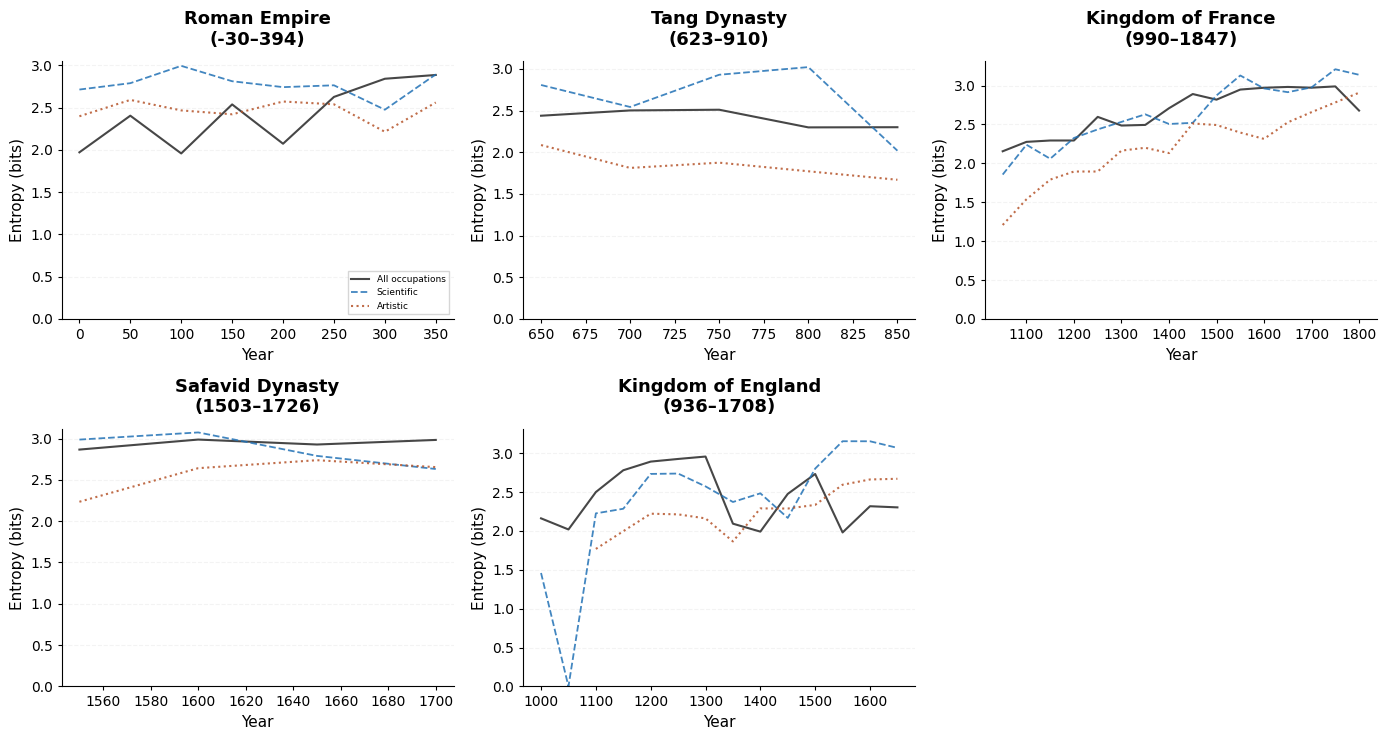

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
axes = axes.flatten()

for idx, (title, yr_start, yr_end, bins, h_all, h_sci, h_art, n) in enumerate(results):
    ax = axes[idx]

    ax.plot(bins, h_all, '-', color='#333333', linewidth=1.5,
            label='All occupations', alpha=0.9)
    ax.plot(bins, h_sci, '--', color='#2171b5', linewidth=1.3,
            label='Scientific', alpha=0.85)
    ax.plot(bins, h_art, ':', color='#b5542a', linewidth=1.5,
            label='Artistic', alpha=0.85)

    ax.set_ylabel('Entropy (bits)', fontsize=11)
    ax.set_xlabel('Year', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=3, labelsize=10)
    ax.grid(axis='y', alpha=0.15, linestyle='--')
    ax.set_ylim(bottom=0)

    ax.set_title(f"{title}\n({yr_start}–{yr_end})",
                 fontsize=13, fontweight='bold', color='black',
                 loc='center', pad=12)

    if idx == 0:
        ax.legend(fontsize=6.5, loc='lower right', frameon=True,
                  fancybox=False, edgecolor='#cccccc')

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

In [4]:
conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

regions = [
    'Chinese World',
    'Arabic world',
    'Indian World',
    'Japan',
    'Persian World',
    'Korea',
]

region_results = []

for region in regions:
    cur = conn.execute('''
        SELECT MIN(c.impact_year), MAX(c.impact_year), COUNT(*)
        FROM consolidate c
        JOIN individuals_regions ir ON c.wikidata_id = ir.wikidata_id
        WHERE ir.region = ?
          AND c.impact_year IS NOT NULL
    ''', (region,))
    yr_start, yr_end, total_count = cur.fetchone()

    print(f"\n{'='*60}")
    print(f"{region}")
    print(f"  Date range: {yr_start} – {yr_end}")
    print(f"  Total individuals: {total_count:,}")

    cur = conn.execute('''
        SELECT c.occupations, c.impact_year, c.is_scientist, c.is_artist
        FROM consolidate c
        JOIN individuals_regions ir ON c.wikidata_id = ir.wikidata_id
        WHERE ir.region = ?
          AND c.occupations IS NOT NULL
          AND c.impact_year IS NOT NULL
    ''', (region,))

    all_counter = Counter()
    sci_counter = Counter()
    art_counter = Counter()
    bin_all = defaultdict(Counter)
    bin_sci = defaultdict(Counter)
    bin_art = defaultdict(Counter)

    n_rows = 0
    for occs_str, year, is_sci, is_art in cur:
        if not occs_str:
            continue
        t = ((year + 25) // 50) * 50
        for occ in occs_str.split('; '):
            occ = occ.strip().lower()
            if not occ:
                continue
            all_counter[occ] += 1
            bin_all[t][occ] += 1
            if is_sci:
                sci_counter[occ] += 1
                bin_sci[t][occ] += 1
            if is_art:
                art_counter[occ] += 1
                bin_art[t][occ] += 1
        n_rows += 1

    top10_all = [o for o, _ in all_counter.most_common(10)]
    top10_sci = [o for o, _ in sci_counter.most_common(10)]
    top10_art = [o for o, _ in art_counter.most_common(10)]

    print(f"  n = {n_rows:,}")
    print(f"\n  Top 10 occupations (from data):")
    for o, c in all_counter.most_common(10):
        print(f"    {o}: {c:,}")
    print(f"\n  Top 10 scientific (from data, is_scientist=1):")
    for o, c in sci_counter.most_common(10):
        print(f"    {o}: {c:,}")
    print(f"\n  Top 10 artistic (from data, is_artist=1):")
    for o, c in art_counter.most_common(10):
        print(f"    {o}: {c:,}")

    complete_bins = sorted(b for b in bin_all
                           if b - 25 >= yr_start and b + 24 <= yr_end)

    h_all = [shannon_entropy(bin_all[b], top10_all) for b in complete_bins]
    h_sci = [shannon_entropy(bin_sci[b], top10_sci) for b in complete_bins]
    h_art = [shannon_entropy(bin_art[b], top10_art) for b in complete_bins]

    if complete_bins:
        print(f"  Plotted bins: {complete_bins[0]} – {complete_bins[-1]}")
    else:
        print("  No complete bins!")

    region_results.append((region, yr_start, yr_end, complete_bins,
                           h_all, h_sci, h_art, n_rows))

conn.close()


Chinese World
  Date range: -1600 – 2024
  Total individuals: 160,633


  n = 85,861

  Top 10 occupations (from data):
    politician: 33,570
    actor: 4,868
    artist: 3,951
    poet: 3,573
    writer: 3,169
    military personnel: 2,699
    singer: 2,019
    painter: 1,994
    film actor: 1,506
    badminton player: 1,477

  Top 10 scientific (from data, is_scientist=1):
    historian: 1,168
    university teacher: 1,137
    politician: 909
    teacher: 533
    chemist: 472
    economist: 464
    researcher: 462
    physicist: 459
    mathematician: 457
    writer: 454

  Top 10 artistic (from data, is_artist=1):
    actor: 4,868
    artist: 3,951
    poet: 3,573
    writer: 3,169
    singer: 2,019
    film actor: 1,506
    television actor: 1,300
    film director: 1,090
    calligrapher: 989
    politician: 958
  Plotted bins: -1250 – 2000



Arabic world
  Date range: -3000 – 2024
  Total individuals: 83,496


  n = 77,247

  Top 10 occupations (from data):
    politician: 9,357
    writer: 8,737
    association football player: 7,385
    actor: 6,289
    journalist: 4,384
    poet: 4,302
    university teacher: 3,007
    singer: 2,747
    painter: 1,907
    basketball player: 1,900

  Top 10 scientific (from data, is_scientist=1):
    university teacher: 3,007
    writer: 2,481
    historian: 1,747
    researcher: 1,190
    poet: 1,067
    politician: 1,040
    teacher: 848
    islamic jurist: 769
    economist: 646
    academic: 630

  Top 10 artistic (from data, is_artist=1):
    writer: 8,736
    actor: 6,289
    poet: 4,302
    singer: 2,747
    journalist: 2,353
    film director: 1,503
    composer: 1,428
    stage actor: 1,278
    screenwriter: 1,158
    translator: 979
  Plotted bins: -2950 – 2000



Indian World
  Date range: -564 – 2024
  Total individuals: 77,034


  n = 70,176

  Top 10 occupations (from data):
    politician: 17,024
    writer: 8,465
    actor: 6,692
    businessperson: 6,678
    cricketer: 4,549
    poet: 3,284
    film director: 2,814
    television actor: 2,095
    singer: 2,029
    journalist: 1,919

  Top 10 scientific (from data, is_scientist=1):
    writer: 1,782
    university teacher: 935
    academic: 804
    historian: 638
    poet: 623
    teacher: 568
    researcher: 487
    ulema: 455
    philosopher: 447
    politician: 444

  Top 10 artistic (from data, is_artist=1):
    writer: 8,465
    actor: 6,692
    poet: 3,284
    film director: 2,814
    television actor: 2,095
    singer: 2,029
    screenwriter: 1,580
    film actor: 1,362
    composer: 977
    film producer: 909
  Plotted bins: -500 – 2000



Japan
  Date range: -452 – 2024
  Total individuals: 187,047


  n = 167,614

  Top 10 occupations (from data):
    politician: 14,817
    actor: 14,783
    businessperson: 10,122
    baseball player: 5,823
    announcer: 5,030
    seiyū: 4,770
    association football player: 4,656
    singer: 4,645
    novelist: 4,285
    composer: 3,574

  Top 10 scientific (from data, is_scientist=1):
    teacher: 3,336
    historian: 3,178
    university teacher: 2,501
    economist: 2,211
    philosopher: 1,067
    researcher: 1,049
    political scientist: 1,033
    linguist: 796
    sociologist: 705
    chemist: 562

  Top 10 artistic (from data, is_artist=1):
    actor: 14,783
    seiyū: 4,770
    singer: 4,645
    novelist: 4,285
    composer: 3,574
    tarento: 3,384
    writer: 3,065
    film director: 2,705
    av idol: 2,448
    owarai tarento: 1,748
  Plotted bins: 350 – 2000



Persian World
  Date range: -1999 – 2024
  Total individuals: 29,883
  n = 24,720

  Top 10 occupations (from data):
    politician: 3,953
    actor: 2,190
    writer: 2,157
    poet: 1,735
    association football player: 1,677
    film director: 1,085
    military personnel: 1,034
    journalist: 1,012
    scientist: 875
    singer: 811

  Top 10 scientific (from data, is_scientist=1):
    scientist: 875
    writer: 672
    university teacher: 497
    historian: 438
    politician: 409
    poet: 349
    translator: 326
    teacher: 302
    academic: 261
    philosopher: 239

  Top 10 artistic (from data, is_artist=1):
    actor: 2,190
    writer: 2,157
    poet: 1,735
    film director: 1,085
    singer: 811
    screenwriter: 644
    composer: 539
    translator: 530
    musician: 512
    journalist: 479
  Plotted bins: -1250 – 2000



Korea
  Date range: -107 – 2024
  Total individuals: 41,989
  n = 37,466

  Top 10 occupations (from data):
    politician: 6,848
    actor: 3,821
    film actor: 3,270
    singer: 2,672
    association football player: 2,306
    television actor: 1,867
    baseball player: 1,867
    stage actor: 1,610
    businessperson: 927
    lawyer: 908

  Top 10 scientific (from data, is_scientist=1):
    academic: 645
    researcher: 328
    university teacher: 243
    philosopher: 205
    politician: 168
    economist: 152
    historian: 140
    professor: 121
    writer: 104
    physicist: 84

  Top 10 artistic (from data, is_artist=1):
    actor: 3,821
    film actor: 3,270
    singer: 2,672
    television actor: 1,867
    stage actor: 1,610
    writer: 820
    voice actor: 783
    film director: 705
    comedian: 630
    poet: 626
  Plotted bins: -50 – 2000


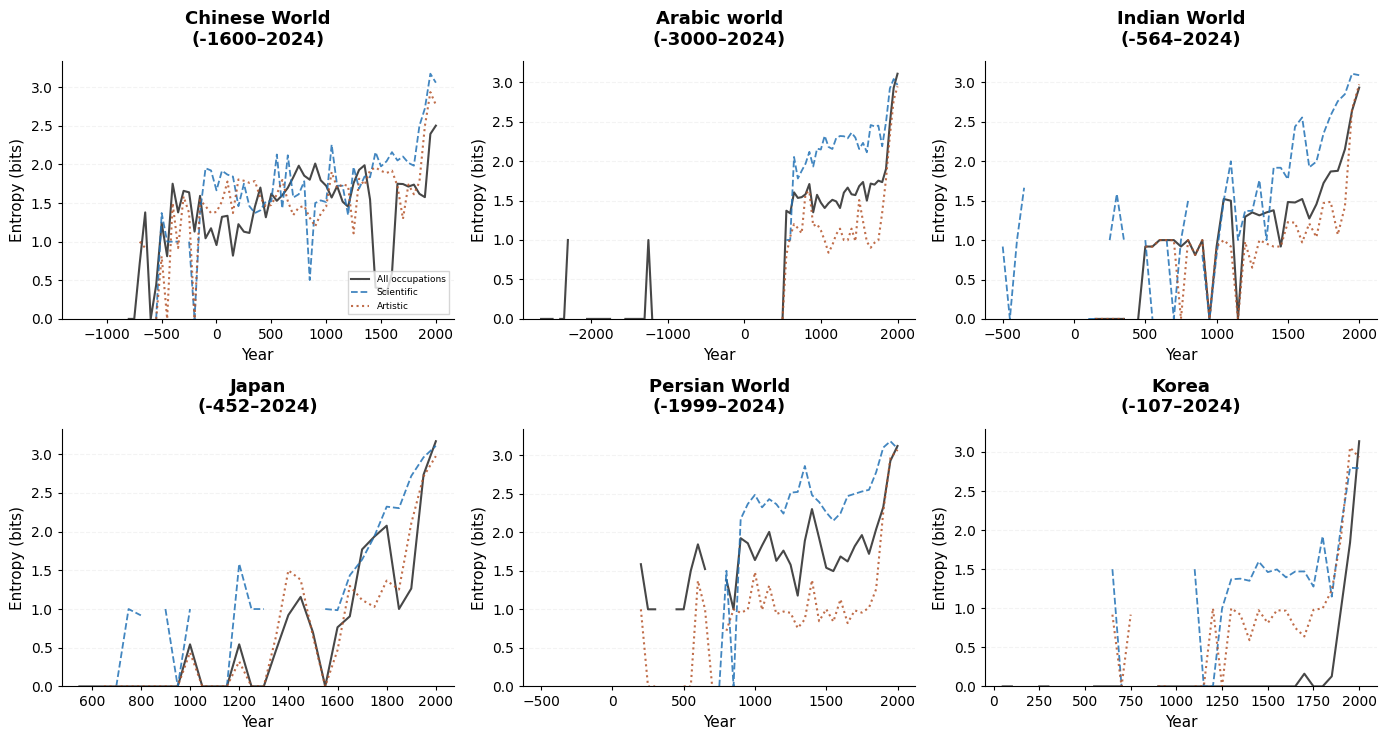

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
axes = axes.flatten()

for idx, (region, yr_start, yr_end, bins, h_all, h_sci, h_art, n) in enumerate(region_results):
    ax = axes[idx]

    ax.plot(bins, h_all, '-', color='#333333', linewidth=1.5,
            label='All occupations', alpha=0.9)
    ax.plot(bins, h_sci, '--', color='#2171b5', linewidth=1.3,
            label='Scientific', alpha=0.85)
    ax.plot(bins, h_art, ':', color='#b5542a', linewidth=1.5,
            label='Artistic', alpha=0.85)

    ax.set_ylabel('Entropy (bits)', fontsize=11)
    ax.set_xlabel('Year', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=3, labelsize=10)
    ax.grid(axis='y', alpha=0.15, linestyle='--')
    ax.set_ylim(bottom=0)

    ax.set_title(f"{region}\n({yr_start}\u2013{yr_end})",
                 fontsize=13, fontweight='bold', color='black',
                 loc='center', pad=12)

    if idx == 0:
        ax.legend(fontsize=6.5, loc='lower right', frameon=True,
                  fancybox=False, edgecolor='#cccccc')

plt.tight_layout()
plt.show()